# Importando as Bibliotecas Básicas e os dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dados = pd.read_csv('https://raw.githubusercontent.com/shivang98/Social-Network-ads-Boost/master/Social_Network_Ads.csv')

In [3]:
dados

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


# Aplicando o Label Encoder na coluna Gender

Para quem tiver dificuldade de ler o código abaixo, olhar a Aula 1 - SVM onde é explicado todo o processo de transformar colunas categóricas em numéricas de forma automática (sem passar pela transformação 1 coluna de cada vez)

In [4]:
colunas = dados.dtypes.reset_index()

categ_cols = colunas[colunas[0] == 'object']['index'].to_list()

# Fazendo encoding das colunas categóricas usando pandas (modo "pandas-like")
# Removemos colunas irrelevantes e transformamos categorias com map/get_dummies

# Remover coluna de identificador se existir
if 'User ID' in dados.columns:
    dados = dados.drop('User ID', axis=1)

# Map para Gender (Male -> 1, Female -> 0) se existir
if 'Gender' in dados.columns:
    dados['Gender_encoded'] = dados['Gender'].map({'Male': 1, 'Female': 0})
    dados = dados.drop('Gender', axis=1)

# Se ainda houver colunas object além do target, aplicamos get_dummies
obj_cols = [c for c in dados.select_dtypes(include=['object']).columns if c != 'Purchased']
if obj_cols:
    dados = pd.get_dummies(dados, columns=obj_cols, drop_first=True)

# Mostrar as primeiras linhas para confirmar
print(dados.dtypes)
dados.head()

Age                int64
EstimatedSalary    int64
Purchased          int64
Gender_encoded     int64
dtype: object


,Age,EstimatedSalary,Purchased,Gender_encoded
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1


In [5]:
dados

,Age,EstimatedSalary,Purchased,Gender_encoded
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1
...,...,...,...,...
395,46,41000,1,0
396,51,23000,1,1
397,50,20000,1,0
398,36,33000,0,1


# Quebrando a base em Treino e Teste

In [6]:
# Seleciona apenas colunas numéricas como features e separa o target
# Isso evita erros ao treinar modelos que esperam dados numéricos (ex: 'Male'/'Female')
x = dados.select_dtypes(include=[np.number]).drop('Purchased', axis=1)
y = dados['Purchased']

# Debug: mostrar tipos das colunas que serão usadas
print(x.dtypes)
x.head()

Age                int64
EstimatedSalary    int64
Gender_encoded     int64
dtype: object


,Age,EstimatedSalary,Gender_encoded
0,19,19000,1
1,35,20000,1
2,26,43000,0
3,27,57000,0
4,19,76000,1


In [7]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x , y, test_size= 0.3, random_state=42)

# Carregando o Modelo

Na nossa base temos dados de clientes + a informação se ele comprou um anúncio oferecido em rede social ou não. Usaremos o Naive Bayes para fazer essa previsão

## Treinando o modelo

In [8]:
from sklearn.naive_bayes import GaussianNB

modelo = GaussianNB()

modelo.fit(x_train,y_train)


,priors,None
,var_smoothing,1e-09


## Fazendo a Previsão

In [9]:
y_pred = modelo.predict(x_test)

In [10]:
y_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0])

# Avaliando o Resultado

In [11]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_pred))

0.925


# Conclusão

Nosso modelo teve uma performance de 88% na acurácia

Isso quer dizer que a taxa de acerto foi muito alta, para uma avaliação adicional, vamos fazer uma matriz de confusão para entender onde estão estes acertos e erros

## Matriz de Confusão

In [12]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred)

array([[72,  1],
       [ 8, 39]])

Text(50.722222222222214, 0.5, 'y_pred')

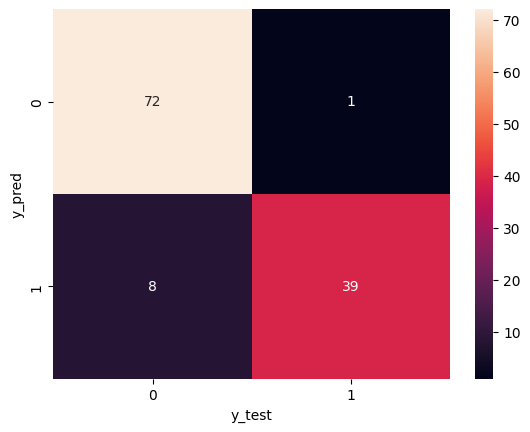

In [13]:
import seaborn as sns


sns.heatmap(confusion_matrix(y_test,y_pred), annot= True)

plt.xlabel('y_test')
plt.ylabel('y_pred')

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))


0.975
0.8297872340425532
0.896551724137931
